<a id="import"></a>
# <center>Import Need Modules</center>

In [1]:
# Google Colab specific imports
from google.colab import drive
# Core libraries
import numpy as np
import pandas as pd
import os
import time
import shutil

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Visualization
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import seaborn as sns
sns.set_style('darkgrid')

# Machine Learning
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Enable mixed precision for faster training on GPU
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('float32')
mixed_precision.set_global_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)
# Keras modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("GPU detected! Training will be fast.")
else:
    print("No GPU detected. Training will be slow.")

Compute dtype: float32
Variable dtype: float32
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected! Training will be fast.


In [2]:
# Install Albumentations (run once in the notebook environment)
# If running locally, you can comment out the pip install line and install via your environment
%pip install albumentations==1.1.0 -q

import albumentations as A
import numpy as np

# Define richer training augmentations to better simulate real-world clutter
train_augment = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.08, rotate_limit=20, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.GridDropout(ratio=0.2, p=0.3),
    A.CoarseDropout(max_holes=1, max_height=50, max_width=50, p=0.3),
], p=1.0)

# Preprocessing function for ImageDataGenerator: apply Albumentations then EfficientNet preprocess
def albumentations_preprocess(image):
    # ImageDataGenerator passes images as float32 arrays in [0,255]
    img_uint8 = image.astype('uint8')
    augmented = train_augment(image=img_uint8)['image']
    # Convert to float32 and apply EfficientNet preprocessing
    return tf.keras.applications.efficientnet.preprocess_input(augmented.astype('float32'))



/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/transforms.py:1952: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


### The size of the images are very large. If you try to use the full image size training will take a very long time. Therefore you
### want to reduce the image size. However if you include resizing of images as part of training it requires each image to be repeatedly
### resized in each epoch. This also make the training times to be large. It is more efficient to resize all the images FIRST and save them.
### Then use these images for training.

<a id="resize"></a>
# <center>Resize all images and save to the working directory</center>

In [3]:
# Mount Google Drive
drive.mount('/content/drive')
start_time=time.time()
sdir = '/content/drive/MyDrive/dataset_train'
working_dir = '/content/cauliflower_training/'
img_height = 300
img_width = 300

# Create working directory first
os.makedirs(working_dir, exist_ok=True)

save_path = os.path.join(working_dir, 'cali')

if os.path.isdir(save_path):
    shutil.rmtree(save_path) # if the directory exists remove it

os.makedirs(save_path, exist_ok=True)  # Changed from os.mkdir() to os.makedirs()

classlist = sorted(os.listdir(sdir))
for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if not os.path.isdir(classpath):  # skip if not a directory
        continue
    print('processing ', klass,  ' class')
    class_dest_path = os.path.join(save_path, klass)
    os.makedirs(class_dest_path, exist_ok=True)  # Changed here too
    flist = os.listdir(classpath)
    for f in flist:
        fpath = os.path.join(classpath,f)
        f_dest_path = os.path.join(class_dest_path, f)
        try: # make sure images are correct image files
            # Use PIL to ensure consistent RGB handling across readers
            with Image.open(fpath) as img:
                img = img.convert('RGB')
                # Use modern resampling API when available
                try:
                    resample_method = Image.Resampling.LANCZOS
                except AttributeError:
                    resample_method = Image.LANCZOS if hasattr(Image, 'LANCZOS') else Image.NEAREST
                img = img.resize((img_height, img_width), resample_method)
                img.save(f_dest_path)
        except Exception as e:
            print('Image ', fpath, ' is an invalid image file:', e)

tr_duration = time.time() - start_time
hours = tr_duration // 3600
minutes = (tr_duration - (hours * 3600)) // 60
seconds = tr_duration - ((hours * 3600) + (minutes * 60))
msg = f'resizing elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
print(msg, flush=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
processing  Alternaria Leaf Spot  class
processing  Bacterial Soft Rot  class
processing  Black Rot  class
processing  Downy Mildew  class
processing  Healthy  class
resizing elapsed time was 0.0 hours,  6.0 minutes, 15.52 seconds)


In [4]:
from PIL import Image
import shutil
import os

sdir = '/content/drive/MyDrive/dataset_train'
quarantine = os.path.join(working_dir, 'quarantine')
os.makedirs(quarantine, exist_ok=True)

moved = 0
for root, _, files in os.walk(sdir):
    for f in files:
        path = os.path.join(root, f)
        # skip if already in quarantine
        try:
            if os.path.commonpath([quarantine, path]) == quarantine:
                continue
        except ValueError:
            # fallback when commonpath can't compare (different path types/drives)
            abs_quarantine = os.path.abspath(quarantine)
            abs_path = os.path.abspath(path)
            if abs_path == abs_quarantine or abs_path.startswith(abs_quarantine + os.sep):
                continue
        try:
            with Image.open(path) as im:
                im.verify()  # will raise if file is truncated or not an image
        except Exception:
            rel = os.path.relpath(path, sdir)
            dest_path = os.path.join(quarantine, rel)
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            try:
                shutil.move(path, dest_path)
                moved += 1
            except Exception as e:
                print('Failed to move', path, '->', dest_path, ':', e)

print(f'Moved {moved} files to quarantine: {quarantine}')

Moved 0 files to quarantine: /content/cauliflower_training/quarantine


<a id="makedf"></a>
# <center>Read in resized images and create a dataframe of image paths and class labels</center>

In [5]:
def make_df(save_path):
    classlist=os.listdir(save_path)
    filepaths=[]
    labels=[]
    for klass in classlist:
        classpath=os.path.join(save_path, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    df=pd.concat([Fseries, Lseries], axis=1)
    train_df, dummy_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df=train_test_split(dummy_df,train_size=.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])
    print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
    # get the number of classes and the images count for each class in train_df
    classes=sorted(list(train_df['labels'].unique()))
    class_count = len(classes)
    print('The number of classes in the dataset is: ', class_count)
    groups=train_df.groupby('labels')
    print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
    countlist=[]
    classlist=[]
    for label in sorted(list(train_df['labels'].unique())):
        group=groups.get_group(label)
        countlist.append(len(group))
        classlist.append(label)
        print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

    # get the classes with the minimum and maximum number of train images
    max_value=np.max(countlist)
    max_index=countlist.index(max_value)
    max_class=classlist[max_index]
    min_value=np.min(countlist)
    min_index=countlist.index(min_value)
    min_class=classlist[min_index]
    print(max_class, ' has the most images= ',max_value, ' ', min_class, ' has the least images= ', min_value)
    # lets get the average height and width of a sample of the train images
    ht=0
    wt=0
    # select 100 random samples of train_df
    train_df_sample=train_df.sample(n=100, random_state=123,axis=0)
    for i in range (len(train_df_sample)):
        fpath=train_df_sample['filepaths'].iloc[i]
        img=plt.imread(fpath)
        shape=img.shape
        ht += shape[0]
        wt += shape[1]
    print('average height= ', ht//100, ' average width= ', wt//100, 'aspect ratio= ', ht/wt)
    return train_df, test_df, valid_df, classes
train_df, test_df, valid_df, classes = make_df(save_path)
class_count=len(classes)

train_df lenght:  6203   test_df length:  776   valid_df length:  775
The number of classes in the dataset is:  5
            CLASS               IMAGE COUNT 
     Alternaria Leaf Spot          1206     
      Bacterial Soft Rot           1121     
          Black Rot                 627     
         Downy Mildew               721     
           Healthy                 2528     
Healthy  has the most images=  2528   Black Rot  has the least images=  627
average height=  300  average width=  300 aspect ratio=  1.0


<a id="balancing_dataset"></a>
# <center>Balancing Dataset</center>

In [6]:
# IMPROVED BALANCE FUNCTION - Now handles both upsampling AND downsampling
def balance(df, n, working_dir, img_size):
    """
    Balance dataset to exactly n samples per class by:
    1. Downsampling majority classes to n
    2. Augmenting minority classes up to n
    """
    df = df.copy()
    print(f'Initial dataframe length: {len(df)}')
    print('\n=== Initial Class Distribution ===')
    initial_dist = df['labels'].value_counts().sort_index()
    print(initial_dist)

    # STEP 1: DOWNSAMPLE majority classes first
    print(f'\n=== Step 1: Downsampling classes with > {n} samples ===')
    balanced_frames = []
    for label in sorted(df['labels'].unique()):
        class_df = df[df['labels'] == label]
        count = len(class_df)

        if count > n:
            class_df = class_df.sample(n=n, random_state=123)
            print(f'✓ Downsampled {label:30s} from {count:4d} to {n}')
        else:
            print(f'  Kept {label:30s} at {count:4d} samples (will augment later)')

        balanced_frames.append(class_df)

    df = pd.concat(balanced_frames, axis=0).reset_index(drop=True)
    print(f'\nAfter downsampling: {len(df)} total samples')

    # STEP 2: AUGMENT minority classes
    print(f'\n=== Step 2: Augmenting classes with < {n} samples ===')
    aug_dir = os.path.join(working_dir, 'aug')
    if os.path.isdir(aug_dir):
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)

    for label in df['labels'].unique():
        dir_path = os.path.join(aug_dir, label)
        os.mkdir(dir_path)

    total_augmented = 0
    gen = ImageDataGenerator(
        horizontal_flip=True,
        rotation_range=20,
        width_shift_range=.2,
        height_shift_range=.2,
        zoom_range=.2
    )

    groups = df.groupby('labels')
    for label in sorted(df['labels'].unique()):
        group = groups.get_group(label)
        sample_count = len(group)

        if sample_count < n:
            delta = n - sample_count
            target_dir = os.path.join(aug_dir, label)
            print(f'✓ Creating {delta:3d} augmented images for {label:30s}')

            aug_gen = gen.flow_from_dataframe(
                group,
                x_col='filepaths',
                y_col=None,
                target_size=img_size,
                class_mode=None,
                batch_size=1,
                shuffle=False,
                save_to_dir=target_dir,
                save_prefix='aug-',
                color_mode='rgb',
                save_format='jpg'
            )

            aug_img_count = 0
            while aug_img_count < delta:
                images = next(aug_gen)
                aug_img_count += len(images)

            total_augmented += aug_img_count

    print(f'\nTotal augmented images created: {total_augmented}')

    # STEP 3: Merge augmented images
    aug_fpaths = []
    aug_labels = []
    classlist = os.listdir(aug_dir)
    for klass in classlist:
        classpath = os.path.join(aug_dir, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            aug_fpaths.append(fpath)
            aug_labels.append(klass)

    if aug_fpaths:
        Fseries = pd.Series(aug_fpaths, name='filepaths')
        Lseries = pd.Series(aug_labels, name='labels')
        aug_df = pd.concat([Fseries, Lseries], axis=1)
        df = pd.concat([df, aug_df], axis=0).reset_index(drop=True)

    print(f'\n=== Final Balanced Distribution ===')
    final_dist = df['labels'].value_counts().sort_index()
    print(final_dist)
    print(f'\nFinal dataframe length: {len(df)}')

    # Verify perfect balance
    if final_dist.nunique() == 1 and final_dist.iloc[0] == n:
        print(f'✓ SUCCESS: All classes perfectly balanced at {n} samples!')
    else:
        print('⚠ WARNING: Classes not perfectly balanced!')

    # Save to CSV
    try:
        merged_csv = os.path.join(working_dir, 'train_balanced.csv')
        df.to_csv(merged_csv, index=False)
        print(f'\n✓ Saved balanced dataset to: {merged_csv}')
    except Exception as e:
        print(f'Warning: could not save CSV: {e}')

    return df

# Apply balancing
n = 600  # Increased from 200 for better model training
working_dir = r'./'
img_size = (300, 300)

print('=' * 80)
print('BALANCING TRAINING DATASET')
print('=' * 80)
train_df = balance(train_df, n, working_dir, img_size)

BALANCING TRAINING DATASET
Initial dataframe length: 6203

=== Initial Class Distribution ===
labels
Alternaria Leaf Spot    1206
Bacterial Soft Rot      1121
Black Rot                627
Downy Mildew             721
Healthy                 2528
Name: count, dtype: int64

=== Step 1: Downsampling classes with > 600 samples ===
✓ Downsampled Alternaria Leaf Spot           from 1206 to 600
✓ Downsampled Bacterial Soft Rot             from 1121 to 600
✓ Downsampled Black Rot                      from  627 to 600
✓ Downsampled Downy Mildew                   from  721 to 600
✓ Downsampled Healthy                        from 2528 to 600

After downsampling: 3000 total samples

=== Step 2: Augmenting classes with < 600 samples ===

Total augmented images created: 0

=== Final Balanced Distribution ===
labels
Alternaria Leaf Spot    600
Bacterial Soft Rot      600
Black Rot               600
Downy Mildew            600
Healthy                 600
Name: count, dtype: int64

Final dataframe leng


<a id="rebuildcleanedcsv"></a>
# <center>Rebuild cleaned CSVs</center>

In [7]:
def write_clean_csv(input_csv, out_csv, quarantine_dir):
    df = pd.read_csv(input_csv)
    # drop any rows whose files were moved to quarantine
    if os.path.isdir(quarantine_dir):
        quarantined = set(os.listdir(quarantine_dir))
        df = df[~df['filepaths'].apply(lambda p: os.path.basename(p) in quarantined)].reset_index(drop=True)
    df.to_csv(out_csv, index=False)
    print('Wrote cleaned CSV:', out_csv)

# Define quarantine_dir (needed if you ran the repair cell earlier)
quarantine_dir = os.path.join(working_dir, 'quarantine')

# Only run if the input CSV exists
input_csv = os.path.join(working_dir, 'train_augmented.csv')
output_csv = os.path.join(working_dir, 'train_augmented_clean.csv')

if os.path.exists(input_csv):
    write_clean_csv(input_csv, output_csv, quarantine_dir)
else:
    print(f'Skipping CSV cleaning - {input_csv} not found yet (run balance function first)')

Skipping CSV cleaning - ./train_augmented.csv not found yet (run balance function first)


<a id="balance"></a>
# <center>Expand train_df by creating augmented images</center>


In [8]:
# Load the balanced dataset (skip if already balanced in memory)
balanced_csv = os.path.join(working_dir, 'train_balanced.csv')

if os.path.exists(balanced_csv):
    print(f"Loading pre-balanced dataset: {balanced_csv}")
    train_df = pd.read_csv(balanced_csv)
    if 'filepaths' not in train_df.columns:
        cols = list(train_df.columns)
        if len(cols) >= 2:
            train_df = train_df.rename(columns={cols[0]: 'filepaths', cols[1]: 'labels'})
    train_df = train_df[['filepaths', 'labels']]

    print(f'\n✓ Loaded balanced dataset: {len(train_df)} samples')
    print('\nClass distribution:')
    print(train_df['labels'].value_counts().sort_index())
else:
    print(f"⚠ {balanced_csv} not found — ensure you ran the balance() function first")

Loading pre-balanced dataset: ./train_balanced.csv

✓ Loaded balanced dataset: 3000 samples

Class distribution:
labels
Alternaria Leaf Spot    600
Bacterial Soft Rot      600
Black Rot               600
Downy Mildew            600
Healthy                 600
Name: count, dtype: int64


<a id="generators"></a>
# <center>Create the train_gen, test_gen final_test_gen and valid_gen</center>

In [9]:
batch_size = 128  # Reduced from 80 for better gradient updates with balanced data
AUTOTUNE = tf.data.AUTOTUNE

# Build class mapping
class_names = sorted(train_df['labels'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
class_count = len(class_names)

# Helper to build tf.data datasets from dataframe
def df_to_dataset(df, training=False):
    paths = df['filepaths'].astype(str).values
    labels = df['labels'].map(class_to_idx).values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=1000, seed=123)
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_train, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_eval, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Functions used by tf.py_function must accept and return numpy-compatible types
def _decode_and_preprocess_train(path, label):
    path = path.numpy().decode('utf-8')
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.uint8).numpy()
    # Albumentations preprocessing returns float32 preprocessed image
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

def _decode_and_preprocess_eval(path, label):
    path = path.numpy().decode('utf-8')
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32).numpy()
    img_pp = tf.keras.applications.efficientnet.preprocess_input(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

print('Creating tf.data datasets...')
train_ds = df_to_dataset(train_df, training=True)
valid_ds = df_to_dataset(valid_df, training=False)
test_ds = df_to_dataset(test_df, training=False)

train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'\n✓ tf.data datasets created successfully')
print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')
print(f'  Number of classes: {class_count}')
# expose variables expected later
classes = class_names
labels = test_df['labels'].map(class_to_idx).values

Creating tf.data datasets...

✓ tf.data datasets created successfully
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7
  Number of classes: 5


In [10]:
def _py_train(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_train, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl


def _py_eval(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_eval, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl

# Rebuild tf.data datasets using the shape-aware wrappers
print('Rebuilding tf.data datasets with fixed shapes...')
train_paths = train_df['filepaths'].astype(str).values
train_labels = train_df['labels'].map(class_to_idx).values.astype('int32')
valid_paths = valid_df['filepaths'].astype(str).values
valid_labels = valid_df['labels'].map(class_to_idx).values.astype('int32')
test_paths = test_df['filepaths'].astype(str).values
test_labels = test_df['labels'].map(class_to_idx).values.astype('int32')

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=1000, seed=123)
train_ds = train_ds.map(_py_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
valid_ds = valid_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
valid_ds = valid_ds.batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

# Recompute steps
train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')

Rebuilding tf.data datasets with fixed shapes...
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7


<a id="class_distribution"></a>
# <center>Check generator class distribution/center>

In [11]:
print('\n=== Dataset Class Distribution ===')
print('Train distribution:')
train_class_dist = train_df['labels'].value_counts().sort_index()
for class_name, count in train_class_dist.items():
    print(f'  {class_name:30s}: {count:4d} samples')

# Compute class weights (even with balanced data, slight weights help)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(class_count),
    y=train_df['labels'].map(class_to_idx).values
)

class_weight_dict = dict(enumerate(class_weights))
print("\n=== Computed Class Weights ===")
for idx, class_name in enumerate(class_names):
    print(f"  {class_name:30s} -> Weight: {class_weight_dict[idx]:.4f}")

print("\n✓ Class weights will provide additional balancing during training")


=== Dataset Class Distribution ===
Train distribution:
  Alternaria Leaf Spot          :  600 samples
  Bacterial Soft Rot            :  600 samples
  Black Rot                     :  600 samples
  Downy Mildew                  :  600 samples
  Healthy                       :  600 samples

=== Computed Class Weights ===
  Alternaria Leaf Spot           -> Weight: 1.0000
  Bacterial Soft Rot             -> Weight: 1.0000
  Black Rot                      -> Weight: 1.0000
  Downy Mildew                   -> Weight: 1.0000
  Healthy                        -> Weight: 1.0000

✓ Class weights will provide additional balancing during training


<a id="show"></a>
# <center>Create a function to show example training images</center>

In [12]:
def show_image_samples_from_df(df, n=25):
    samp = df.sample(n=min(n, len(df)), random_state=123)
    plt.figure(figsize=(20, 20))
    for i, (_, row) in enumerate(samp.iterrows()):
        plt.subplot(5, 5, i + 1)
        img = Image.open(row['filepaths']).convert('RGB')
        img = img.resize((img_size[1], img_size[0]))
        plt.imshow(np.array(img) / 255.0)
        plt.title(row['labels'], color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples_from_df(train_df)

Output hidden; open in https://colab.research.google.com to view.

<a id="model"></a>
# <center>Create a model using transfer learning with EfficientNetB3</center>
### NOTE experts advise you make the base model initially not trainable. Then train for some number of epochs
### then fine tune model by making base model trainable and run more epochs
### I have found this to be WRONG!!!!
### Making the base model trainable from the outset leads to faster convegence and a lower validation loss
### for the same number of total epochs!

In [13]:
img_shape = (img_size[0], img_size[1], 3)
model_name = 'EfficientNetB3'

print(f'Building {model_name} model...')

# Create base model
base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model with MODERATE regularization
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# Add intermediate layer for better feature learning
x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.45, seed=123)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.35, seed=123)(x)

# Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model with lower initial learning rate
lr = 0.0005  # Reduced from 0.001 for more stable training
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\n✓ Model compiled with learning rate: {lr}')
print(f'  Total parameters: {model.count_params():,}')
model.summary()

Building EfficientNetB3 model...

✓ Model compiled with learning rate: 0.0005
  Total parameters: 11,709,236


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,709,236 (44.67 MB)

 Trainable params: 11,618,861 (44.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

<a id="callback"></a>
# <center>Create a custom Keras callback to continue and optionally set LR or halt training</center>
The LR_ASK callback is a convenient callback that allows you to continue training for ask_epoch more epochs or to halt training.  
If you elect to continue training for more epochs you are given the option to retain the current learning rate (LR) or to  
enter a new value for the learning rate. The form of use is:  
ask=LR_ASK(model,epochs, ask_epoch) where:  
* model is a string which is the name of your compiled model
* epochs is an integer which is the number of epochs to run specified in model.fit
* ask_epoch is an integer. If ask_epoch is set to a value say 5 then the model will train for 5 epochs.  
  then the user is ask to enter H to halt training, or enter an inter value. For example if you enter 4  
  training will continue for 4 more epochs to epoch 9 then you will be queried again. Once you enter an  
  integer value you are prompted to press ENTER to continue training using the current learning rate  
  or to enter a new value for the learning rate.  
  
 At the end of training the model weights are set to the weights for the epoch that achieved the lowest validation loss

In [14]:
class LR_ASK(keras.callbacks.Callback):
    def __init__ (self, model, epochs,  ask_epoch): # initialization of the callback
        super(LR_ASK, self).__init__()
        self.user_model=model  # Changed from self.model to self.user_model
        self.ask_epoch=ask_epoch
        self.epochs=epochs
        self.ask=True # if True query the user on a specified epoch
        self.lowest_vloss=np.inf
        self.best_weights=self.user_model.get_weights() # Changed to self.user_model
        self.best_epoch=1


    def on_train_begin(self, logs=None): # this runs on the beginning of training
        if self.ask_epoch == 0:
            print('you set ask_epoch = 0, ask_epoch will be set to 1', flush=True)
            self.ask_epoch=1
        if self.ask_epoch >= self.epochs: # you are running for epochs but ask_epoch>epochs
            print('ask_epoch >= epochs, will train for ', epochs, ' epochs', flush=True)
            self.ask=False # do not query the user
        if self.epochs == 1:
            self.ask=False # running only for 1 epoch so do not query user
        else:
            print('Training will proceed until epoch', ask_epoch,' then you will be asked to')
            print(' enter H to halt training or enter an integer for how many more epochs to run then be asked again')
        self.start_time= time.time() # set the time at which training started

    def on_train_end(self, logs=None):   # runs at the end of training
        print('loading model with weights from epoch ', self.best_epoch)
        self.user_model.set_weights(self.best_weights) # Changed to self.user_model
        tr_duration=time.time() - self.start_time   # determine how long the training cycle lasted
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print (msg, flush=True) # print out training duration time

    def on_epoch_end(self, epoch, logs=None):  # method runs on the end of each epoch
        v_loss=logs.get('val_loss')  # get the validation loss for this epoch
        if v_loss< self.lowest_vloss:
            self.lowest_vloss=v_loss
            self.best_weights=self.user_model.get_weights() # Changed to self.user_model
            self.best_epoch=epoch + 1
            print (f'\n validation loss of {v_loss:7.4f} is below lowest loss, saving weights from epoch {str(epoch + 1):3s} as best weights')
        else:
            print (f'\n validation loss of {v_loss:7.4f} is above lowest loss of {self.lowest_vloss:7.4f} keeping weights from epoch {str(self.best_epoch)} as best weights')

        if self.ask: # are the conditions right to query the user?
            if epoch + 1 ==self.ask_epoch: # is this epoch the one for quering the user?
                print('\n Enter H to end training or  an integer for the number of additional epochs to run then ask again')
                ans=input()

                if ans == 'H' or ans =='h' or ans == '0': # quit training for these conditions
                    print ('you entered ', ans, ' Training halted on epoch ', epoch+1, ' due to user input\n', flush=True)
                    self.model.stop_training = True # halt training (this self.model is the Keras callback's model)
                else: # user wants to continue training
                    self.ask_epoch += int(ans)
                    if self.ask_epoch > self.epochs:
                        print('\nYou specified maximum epochs of as ', self.epochs, ' cannot train for ', self.ask_epoch, flush =True)
                    else:
                        print ('you entered ', ans, ' Training will continue to epoch ', self.ask_epoch, flush=True)
                        # Fixed: Changed from .lr to .learning_rate
                        lr=float(tf.keras.backend.get_value(self.user_model.optimizer.learning_rate))
                        print(f'current LR is  {lr:7.5f}  hit enter to keep  this LR or enter a new LR')
                        ans=input(' ')
                        if ans =='':
                            print (f'keeping current LR of {lr:7.5f}')
                        else:
                            new_lr=float(ans)
                            # Fixed: Changed from .lr to .learning_rate
                            tf.keras.backend.set_value(self.user_model.optimizer.learning_rate, new_lr)
                            print(' changing LR to ', ans)

<a id="callbacks"></a>
# <center>Instantiate custom callback

In [15]:
os.makedirs(quarantine_dir, exist_ok=True)

def _decode_and_preprocess_train(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.uint8)
    except Exception as e:
        # Move problematic file to quarantine to avoid repeated failures
        try:
            dest = os.path.join(quarantine_dir, os.path.basename(p))
            shutil.move(p, dest)
            print('Quarantined bad file:', p)
        except Exception:
            pass
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.uint8)
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe


def _decode_and_preprocess_eval(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.float32)
    except Exception:
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
    img_pp = tf.keras.applications.efficientnet.preprocess_input(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

# Rebuild TF datasets using the shape-aware wrappers defined earlier
print('Rebuilding tf.data datasets with robust PIL loaders...')
train_paths = train_df['filepaths'].astype(str).values
train_labels = train_df['labels'].map(class_to_idx).values.astype('int32')
valid_paths = valid_df['filepaths'].astype(str).values
valid_labels = valid_df['labels'].map(class_to_idx).values.astype('int32')
test_paths = test_df['filepaths'].astype(str).values
test_labels = test_df['labels'].map(class_to_idx).values.astype('int32')

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=1000, seed=123)
train_ds = train_ds.map(_py_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
valid_ds = valid_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
valid_ds = valid_ds.batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

# Recompute steps
train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')

Rebuilding tf.data datasets with robust PIL loaders...
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7


In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

epochs = 150  # Increased for better convergence

# Save best model to Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=4,  # Wait 3 epochs before reducing
    min_lr=1e-7,
    verbose=1,
    mode='min'
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,  # Increased patience for better training
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

callbacks = [checkpoint, reduce_lr, early_stop]
print('✓ Callbacks configured:')

✓ Callbacks configured:


<a id="train"></a>
# <center>Train the model
### Note unlike how you are told it is BETTER to make the base model trainable from the outset
### It will converge faster and have a lower validation losss

In [17]:
print('STARTING TRAINING')
print('=' * 80)
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')
print(f'Steps per epoch: {train_steps}')
print(f'Validation steps: {valid_steps}')
print('=' * 80)

history = model.fit(
    x=train_ds,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_ds,
    steps_per_epoch=train_steps,
    validation_steps=valid_steps,
    shuffle=False,
    initial_epoch=0
)

print('\n✓ Training completed!')

STARTING TRAINING
Epochs: 150
Batch size: 128
Steps per epoch: 24
Validation steps: 7
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4333 - loss: 3.0678   
Epoch 1: val_loss improved from inf to 2.99970, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 440s 9s/step - accuracy: 0.4319 - loss: 3.0780 - val_accuracy: 0.5071 - val_loss: 2.9997 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.3664 - loss: 2.8209
Epoch 2: val_loss did not improve from 2.99970
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 758ms/step - accuracy: 0.3709 - loss: 2.8078 - val_accuracy: 0.4426 - val_loss: 3.0399 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.5944 - loss: 2.1612
Epoch 3: val_loss improved from 2.99970 to 2.40780, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 892ms/step - accuracy: 0.5964 - loss: 2.1575 - val_accuracy: 0.5974 - val_loss: 2.4078 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.6577 - loss: 1.9481
Epoch 4: val_loss improved from 2.40780 to 1.80148, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 819ms/step - accuracy: 0.6594 - loss: 1.9447 - val_accuracy: 0.7432 - val_loss: 1.8015 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.7470 - loss: 1.7310
Epoch 5: val_loss improved from 1.80148 to 1.40463, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 892ms/step - accuracy: 0.7481 - loss: 1.7291 - val_accuracy: 0.8787 - val_loss: 1.4046 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.7524 - loss: 1.7050
Epoch 6: val_loss improved from 1.40463 to 1.27108, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


...

24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 885ms/step - accuracy: 0.9996 - loss: 0.1624 - val_accuracy: 0.9974 - val_loss: 0.1694 - learning_rate: 5.0000e-04
Epoch 146/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9996 - loss: 0.1587
Epoch 146: val_loss improved from 0.16940 to 0.16890, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 967ms/step - accuracy: 0.9996 - loss: 0.1587 - val_accuracy: 0.9961 - val_loss: 0.1689 - learning_rate: 5.0000e-04
Epoch 147/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9996 - loss: 0.1542
Epoch 147: val_loss improved from 0.16890 to 0.16480, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 878ms/step - accuracy: 0.9996 - loss: 0.1542 - val_accuracy: 0.9961 - val_loss: 0.1648 - learning_rate: 5.0000e-04
Epoch 148/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9998 - loss: 0.1502
Epoch 148: val_loss improved from 0.16480 to 0.15907, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 882ms/step - accuracy: 0.9998 - loss: 0.1502 - val_accuracy: 0.9961 - val_loss: 0.1591 - learning_rate: 5.0000e-04
Epoch 149/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.9995 - loss: 0.1479
Epoch 149: val_loss did not improve from 0.15907
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 755ms/step - accuracy: 0.9995 - loss: 0.1479 - val_accuracy: 0.9961 - val_loss: 0.1611 - learning_rate: 5.0000e-04
Epoch 150/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.9989 - loss: 0.1454
Epoch 150: val_loss improved from 0.15907 to 0.15092, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 882ms/step - accuracy: 0.9989 - loss: 0.1455 - val_accuracy: 0.9974 - val_loss: 0.1509 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 150.

✓ Training completed!


<a id="trainingnvalidation"></a>
# <center>Training&Validation Test

In [18]:
print('\n' + '=' * 80)
print('POST-TRAINING ANALYSIS')
print('=' * 80)

# Check final metrics
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f'\nFinal Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_acc:.4f}')
print(f'Final Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_acc:.4f}')

# Find best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f'\nBest Epoch: {best_epoch}')
print(f'  Validation Loss: {best_val_loss:.4f}')
print(f'  Validation Accuracy: {best_val_acc:.4f}')

# Quick sanity check on a few predictions
print('\n🔍 Quick Prediction Check (first 10 validation samples):')
val_batch, val_labels_batch = next(iter(valid_ds))
val_predictions = model.predict(val_batch[:10])
val_pred_classes = np.argmax(val_predictions, axis=1)
val_class_names = [classes[i] for i in val_pred_classes]
print('Predicted classes:', val_class_names)

unique_preds = np.unique(val_pred_classes)
if len(unique_preds) > 1:
    print('✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!')
else:
    print('⚠️ WARNING: Model still predicting only one class. Check training logs.')

print('=' * 80)


POST-TRAINING ANALYSIS

Final Training   - Loss: 0.1462, Accuracy: 0.9983
Final Validation - Loss: 0.1509, Accuracy: 0.9974

Best Epoch: 150
  Validation Loss: 0.1509
  Validation Accuracy: 0.9974

🔍 Quick Prediction Check (first 10 validation samples):
1/1 ━━━━━━━━━━━━━━━━━━━━ 36s 36s/step
Predicted classes: ['Healthy', 'Black Rot', 'Alternaria Leaf Spot', 'Alternaria Leaf Spot', 'Healthy', 'Downy Mildew', 'Bacterial Soft Rot', 'Black Rot', 'Alternaria Leaf Spot', 'Downy Mildew']
✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!


<a id="plot"></a>
# <center>Define a function to plot the training data

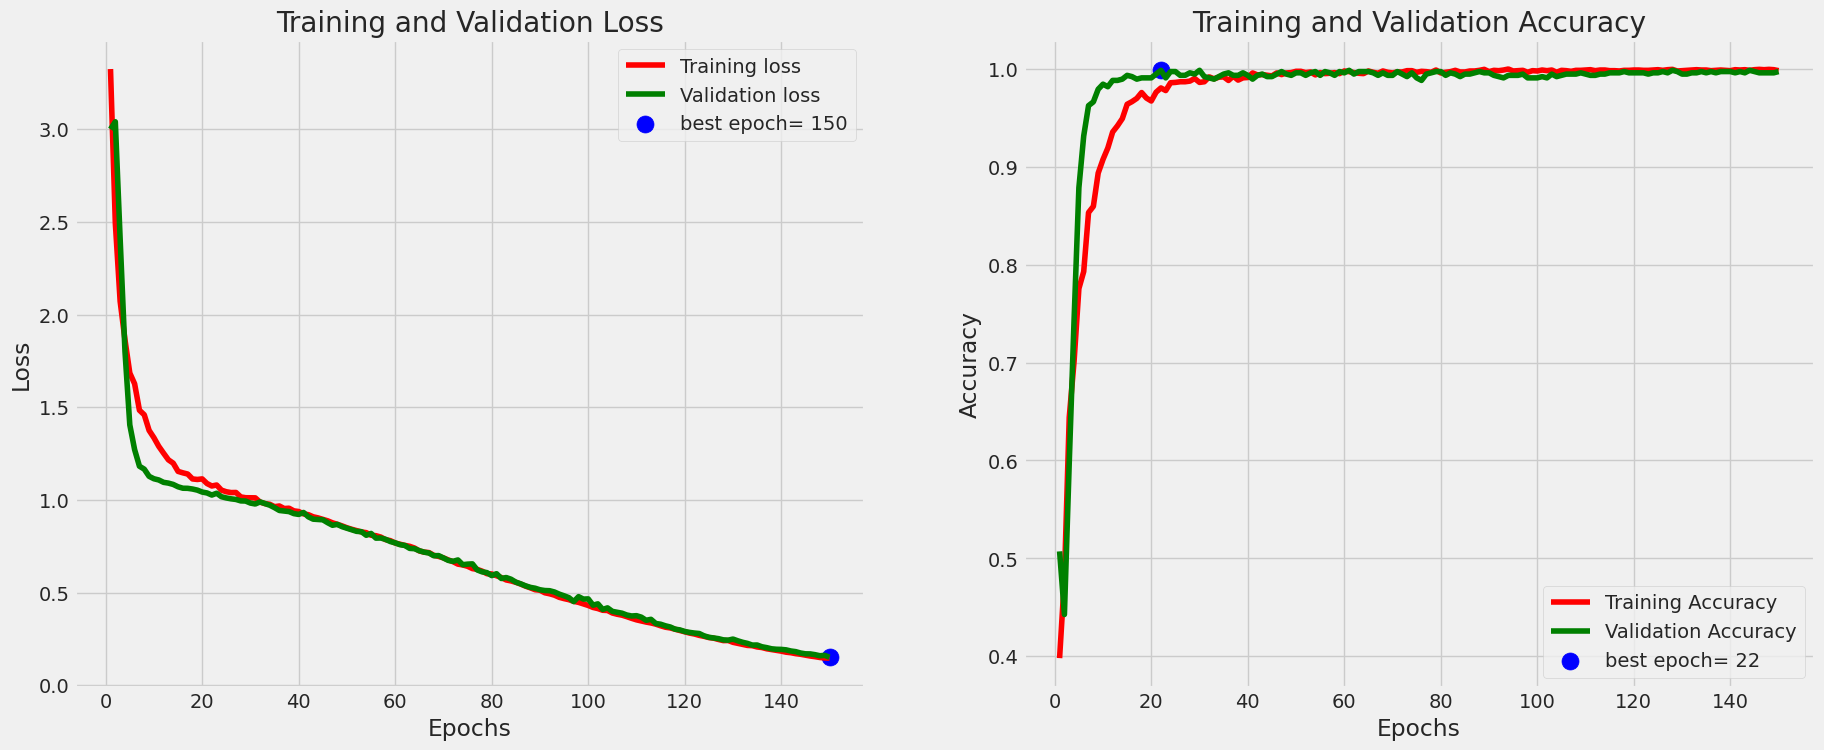

In [19]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

<a id="result"></a>
# <center>Make Predictions on the test set</a>
### Define a function which takes in a test generator and an integer test_steps
### and generates predictions on the test set including a confusion matric
### and a classification report

7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0064.jpg  was an error
file  /content/cauliflower_training/cali/Downy Mildew/downy_mildew_0985.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0002.jpg  was an error
there were 3 errors in 776 tests for an accuracy of  99.61


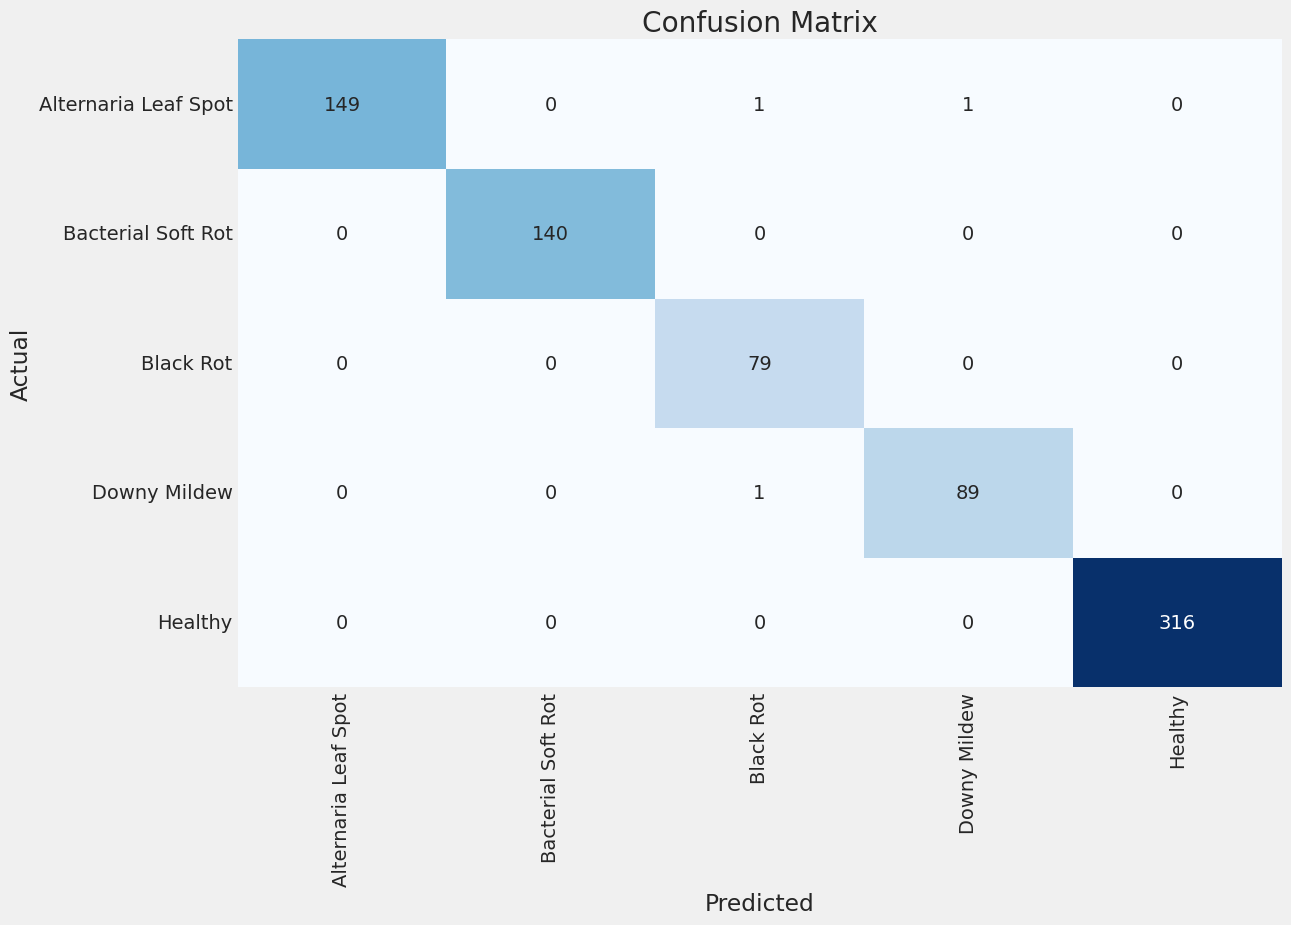

Classification Report:
----------------------
                       precision    recall  f1-score   support

Alternaria Leaf Spot     1.0000    0.9868    0.9933       151
  Bacterial Soft Rot     1.0000    1.0000    1.0000       140
           Black Rot     0.9753    1.0000    0.9875        79
        Downy Mildew     0.9889    0.9889    0.9889        90
             Healthy     1.0000    1.0000    1.0000       316

            accuracy                         0.9961       776
           macro avg     0.9928    0.9951    0.9939       776
        weighted avg     0.9962    0.9961    0.9961       776



In [20]:
def predictor_from_df(test_df, test_ds):
    y_true = test_df['labels'].map(class_to_idx).values
    filepaths = test_df['filepaths'].values
    class_names_local = class_names
    errors = 0
    preds = model.predict(test_ds, verbose=1)
    pred_indices = np.argmax(preds, axis=1)
    for i, (p, t) in enumerate(zip(pred_indices, y_true)):
        if p != t:
            errors += 1
            print('file ', filepaths[i], ' was an error')

    acc = (1 - errors/len(y_true)) * 100
    print(f'there were {errors} errors in {len(y_true)} tests for an accuracy of {acc:6.2f}')

    cm = confusion_matrix(y_true, pred_indices)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(np.arange(class_count)+.5, class_names_local, rotation=90)
    plt.yticks(np.arange(class_count)+.5, class_names_local, rotation=0)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    clr = classification_report(y_true, pred_indices, target_names=class_names_local, digits=4)
    print("Classification Report:\n----------------------\n", clr)
    return errors, len(y_true)

errors, tests = predictor_from_df(test_df, test_ds)

<a id="save"></a>
# <center>Save the model

In [21]:
subject='nuts'
acc=str(( 1-errors/tests) * 100)
index=acc.rfind('.')
acc=acc[:index + 3]
save_id= subject + '_' + str(acc) + '.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc )


model was saved as  ./nuts_99.61.h5
